In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [29]:
X = pd.read_csv("../data/processed/X_docetaxel.csv")
y = pd.read_csv("../data/processed/y_docetaxel.csv")

In [30]:
print("X Shape:", X.shape)
print("y shape:", y.shape)

X Shape: (651, 36418)
y shape: (651, 2)


In [31]:
X.head()

,SANGER_MODEL_ID,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZZEF1,ZZZ3
0,SIDM01132,5.1375,3.3840,0.0000,0.6135,0.0000,0.0426,0.0000,0.0,0.0000,...,6.1305,0.4751,1.8992,3.7623,0.9928,0.0,2.8258,6.4130,4.1554,4.0575
1,SIDM00848,4.8689,3.4476,0.0000,1.9964,0.1243,3.1890,0.0000,0.0,0.0000,...,7.0915,1.6826,2.3306,5.1863,0.0841,0.0,3.0993,5.5242,3.6064,4.5211
2,SIDM00263,5.0365,3.5558,0.0144,3.9855,0.2987,5.7968,0.0566,0.0,0.1375,...,5.6966,2.9486,3.3923,6.5963,4.1787,0.0,4.6809,6.3778,4.5759,5.6946
3,SIDM00269,4.5497,3.8001,0.0841,3.2157,0.0566,0.5753,0.0000,0.0,0.0841,...,4.5392,2.8298,3.4128,6.7827,2.3190,0.0,4.2141,9.0105,4.9340,5.4561
4,SIDM00203,4.2250,3.2095,0.0144,0.5059,0.0976,2.8156,0.0000,0.0,0.0704,...,6.4510,2.4957,3.4764,5.3071,3.0321,0.0,4.4731,6.9529,4.3590,5.3366


In [32]:
X = X.set_index('SANGER_MODEL_ID')

In [33]:
X.head()

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZZEF1,ZZZ3
SANGER_MODEL_ID,,,,,,,,,,,,,,,,,,,,,
SIDM01132,5.1375,3.3840,0.0000,0.6135,0.0000,0.0426,0.0000,0.0,0.0000,0.0841,...,6.1305,0.4751,1.8992,3.7623,0.9928,0.0,2.8258,6.4130,4.1554,4.0575
SIDM00848,4.8689,3.4476,0.0000,1.9964,0.1243,3.1890,0.0000,0.0,0.0000,0.0841,...,7.0915,1.6826,2.3306,5.1863,0.0841,0.0,3.0993,5.5242,3.6064,4.5211
SIDM00263,5.0365,3.5558,0.0144,3.9855,0.2987,5.7968,0.0566,0.0,0.1375,0.1110,...,5.6966,2.9486,3.3923,6.5963,4.1787,0.0,4.6809,6.3778,4.5759,5.6946
SIDM00269,4.5497,3.8001,0.0841,3.2157,0.0566,0.5753,0.0000,0.0,0.0841,0.1506,...,4.5392,2.8298,3.4128,6.7827,2.3190,0.0,4.2141,9.0105,4.9340,5.4561
SIDM00203,4.2250,3.2095,0.0144,0.5059,0.0976,2.8156,0.0000,0.0,0.0704,0.2141,...,6.4510,2.4957,3.4764,5.3071,3.0321,0.0,4.4731,6.9529,4.3590,5.3366


In [34]:
y.head()

,SANGER_MODEL_ID,AUC
0,SIDM01132,0.267990
1,SIDM00848,0.105028
2,SIDM00263,0.195845
3,SIDM00269,0.082177
4,SIDM00203,0.302620


In [35]:
y = y.set_index('SANGER_MODEL_ID')

In [36]:
y.head()

,AUC
SANGER_MODEL_ID,
SIDM01132,0.267990
SIDM00848,0.105028
SIDM00263,0.195845
SIDM00269,0.082177
SIDM00203,0.302620


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
for n in [50, 100, 200]:
    pca = PCA(n_components=n)
    
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    print(
        f"{n} components → "
        f"{pca.explained_variance_ratio_.sum():.2%} variance explained"
    )

50 components → 45.79% variance explained
100 components → 57.88% variance explained
200 components → 73.93% variance explained


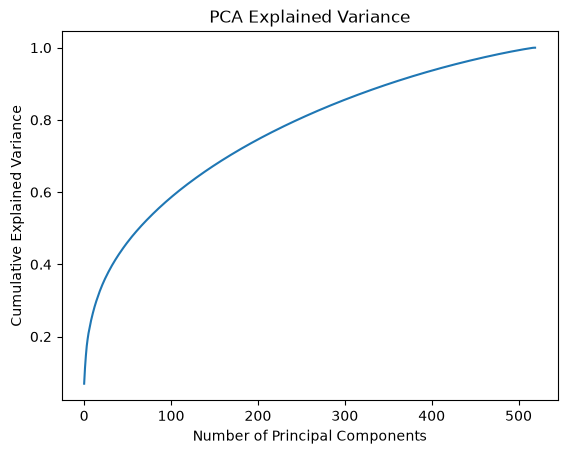

In [55]:
import matplotlib.pyplot as plt

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [76]:
pca = PCA(n_components=200)
    
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [77]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_pca, y_train.values.ravel())

y_pred_linear = linear_model.predict(X_test_pca)

In [78]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse_linear = root_mean_squared_error(
    y_test,
    y_pred_linear
)

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

In [81]:
print("PCA + Linear Regression")
print("RMSE:", rmse_linear)
print("MAE:", mae_linear)
print("R²:", r2_linear)

PCA + Linear Regression
RMSE: 0.2751118952520807
MAE: 0.22884055719111468
R²: 0.1632918879303885


In [82]:
y_train_pred_linear = linear_model.predict(X_train_pca)

train_r2_linear = r2_score(
    y_train,
    y_train_pred_linear
)

print("Train R²:", train_r2_linear)
print("Test R²:", r2_linear)

Train R²: 0.6372996299104322
Test R²: 0.1632918879303885
